In [1]:
import subprocess, sys

result = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', 
     'cohere', 'playwright', 
     'beautifulsoup4', 'lxml', 'streamlit', 'python-dotenv'],
    capture_output=True, text=True
)
print(result.stdout)

In [2]:
import urllib.request, json, os
from dotenv import load_dotenv
load_dotenv()

key = os.environ.get("OPENROUTER_API_KEY", "")

req = urllib.request.Request(
    "https://openrouter.ai/api/v1/models",
    headers={"Authorization": f"Bearer {key}"},
)

with urllib.request.urlopen(req) as r:
    models = json.loads(r.read().decode())["data"]

# Filter for truly free models (pricing = 0)
free = [
    m for m in models
    if float(m.get("pricing", {}).get("prompt", 1)) == 0
    and float(m.get("pricing", {}).get("completion", 1)) == 0
]

print(f"Free models available: {len(free)}")
for m in free[:10]:
    print(f"  {m['id']}")

Free models available: 26
  nex-agi/nex-n2-pro:free
  nvidia/nemotron-3.5-content-safety:free
  nvidia/nemotron-3-ultra-550b-a55b:free
  openrouter/owl-alpha
  nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free
  poolside/laguna-xs.2:free
  poolside/laguna-m.1:free
  google/gemma-4-26b-a4b-it:free
  google/gemma-4-31b-it:free
  google/lyria-3-pro-preview


In [3]:
import os

os.environ['COHERE_API_KEY'] = 'YOUR_API_KEY_HERE'

key = os.environ.get('COHERE_API_KEY', '')
print(f'API key set: {key[:10]}...' if len(key) > 10 else 'NOT SET')

API key set: YOUR_API_K...


In [ ]:
## Phase 1: Scrape a Turo listing

import subprocess, sys

TURO_URL = 'YOUR_URL_HERE_TO_SCRAP'

result = subprocess.run(
    [sys.executable, 'scraper.py', TURO_URL],
    capture_output=True, text=True, timeout=120
)
print(result.stdout)
if result.returncode != 0:
    print('--- STDERR ---')
    print(result.stderr)


  1Now — Phase 1: Turo Scraper

[*] Navigating → https://turo.com/us/en/suv-rental/united-states/rogers-ar/gmc/terrain/2932476?endDate=07%2F15%2F2026&endTime=10%3A00&searchId=vBxlzwZ6&startDate=07%2F12%2F2026&startTime=10%3A00
[*] Scrolling to load dynamic content...
[✓] Saved → output/raw.html
[✓] Saved → output/screenshot.png
[*] Parsing listing data...
[✓] Saved → output\listing_data.json

────────────────────────────────────────
  Vehicle  : GMC Terrain 2024 rental in Rogers, AR by Ryan | Turo
  Price    : $66.5/day
  Rating   : 5  (None trips)
  Host     : N/A  [N/A trips hosted]
  Location : Rogers, AR
  Specs    : {'mpg': '26', 'seats': '5', 'transmission': 'Automatic', 'fuel_type': 'Electric'}
  Features : 18 items
  Reviews  : 4 found
  Desc len : 157 chars
────────────────────────────────────────

Phase 1 done. Feed output/listing_data.json into pipeline.py next.



In [5]:
##  Inspect scraper output
import json
from pathlib import Path

listing_path = Path('output/listing_data.json')

if not listing_path.exists():
    print('listing_data.json not found — scraper may have failed. Check output/screenshot.png')
else:
    listing = json.loads(listing_path.read_text())
    v = listing.get('vehicle', {})
    h = listing.get('host', {})
    d = listing.get('details', {})
    r = listing.get('reviews', [])

    print('=== VEHICLE ===')
    print(f"  Name         : {v.get('name')}")
    print(f"  Price/day    : {v.get('price_per_day')}")
    print(f"  Rating       : {v.get('rating')}  ({v.get('trip_count')} trips)")

    print('\n=== HOST ===')
    print(f"  Name         : {h.get('name')}")
    print(f"  Trips hosted : {h.get('trips_hosted')}")
    print(f"  Response rate: {h.get('response_rate')}")
    print(f"  Member since : {h.get('member_since')}")

    print('\n=== DETAILS ===')
    print(f"  Location     : {d.get('location')}")
    print(f"  Specs        : {d.get('specs')}")
    print(f"  Features     : {len(d.get('features', []))} items")
    print(f"  Desc length  : {len(d.get('description', ''))} chars")

    print(f'\n=== REVIEWS === ({len(r)} found)')
    for i, rev in enumerate(r[:3]):
        txt = rev.get('text', '')[:120]
        print(f"  [{i+1}] {txt}...")

    print('\n--- NA CHECK ---')
    na_fields = [
        ('vehicle.name',        v.get('name') == 'N/A'),
        ('vehicle.price',       v.get('price_per_day') == 'N/A'),
        ('host.name',           h.get('name') == 'N/A'),
        ('details.description', d.get('description') == 'N/A'),
        ('reviews empty',       len(r) == 0),
    ]
    issues = [f for f, bad in na_fields if bad]
    if issues:
        print(f'  Fields that came back empty: {issues}')
        print('  Tip: open output/screenshot.png to see what the browser loaded.')
    else:
        print('  All key fields populated. Good to proceed.')

=== VEHICLE ===
  Name         : GMC Terrain 2024 rental in Rogers, AR by Ryan | Turo
  Price/day    : $66.5/day
  Rating       : 5  (None trips)

=== HOST ===
  Name         : N/A
  Trips hosted : N/A
  Response rate: N/A
  Member since : N/A

=== DETAILS ===
  Location     : Rogers, AR
  Specs        : {'mpg': '26', 'seats': '5', 'transmission': 'Automatic', 'fuel_type': 'Electric'}
  Features     : 18 items
  Desc length  : 157 chars

=== REVIEWS === (4 found)
  [1] Eric • June 5, 2026Great car, well maintained. Easy pickup and return, and excellent communication. Highly recommended....
  [2] Connor • May 24, 2026Great communication, car as expected...
  [3] CHRISTOPHER • April 26, 2026Everything was great!...

--- NA CHECK ---
  Fields that came back empty: ['host.name']
  Tip: open output/screenshot.png to see what the browser loaded.


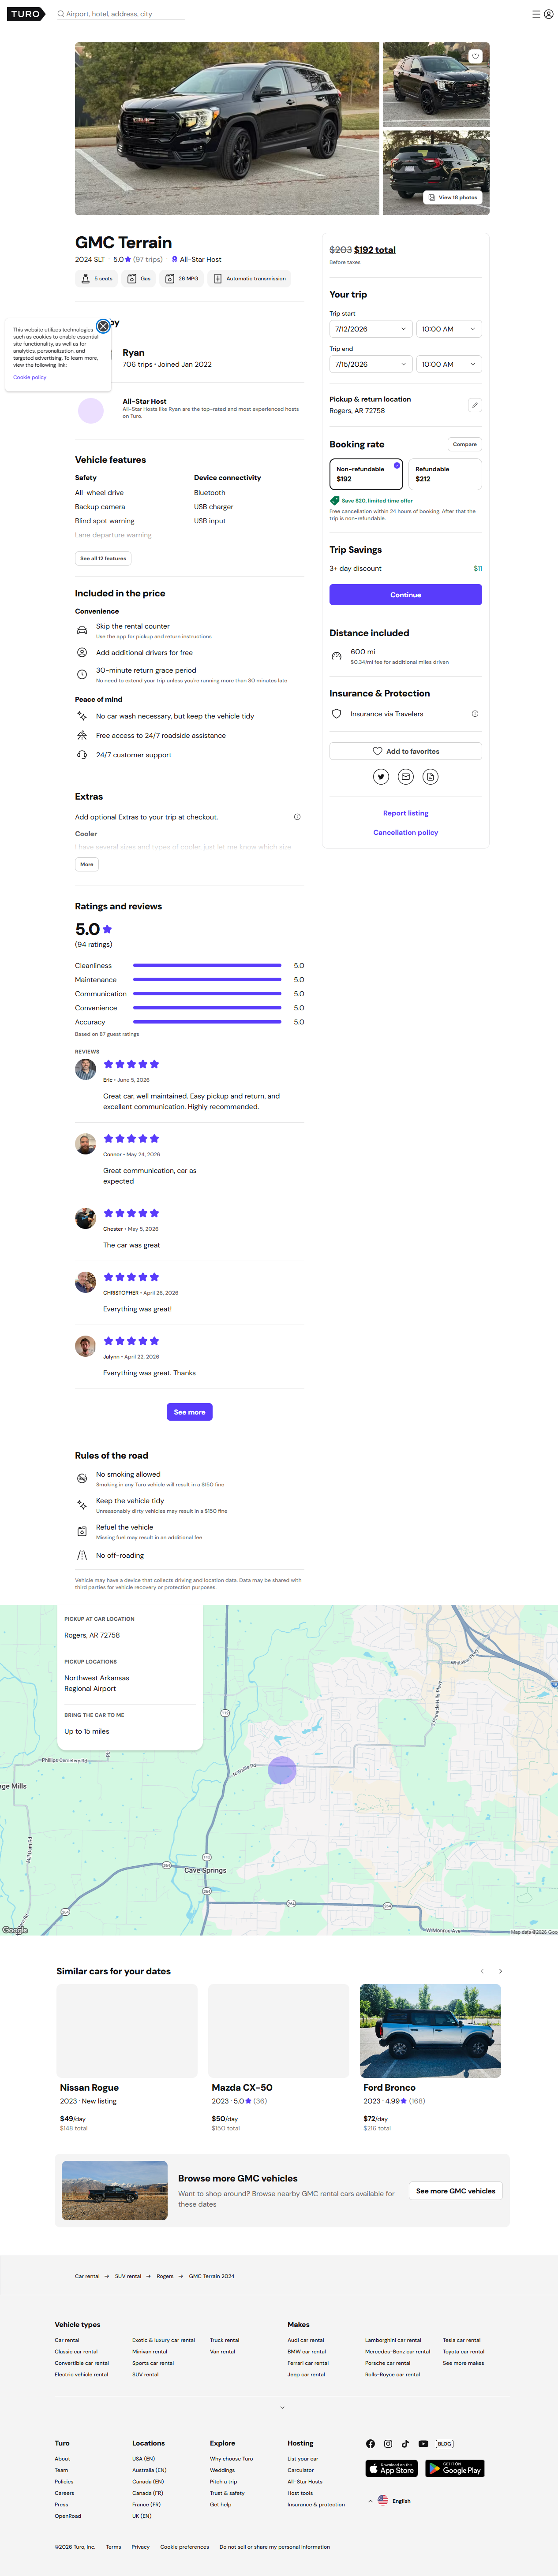

In [6]:
## View browser screenshot (debug)

from IPython.display import Image, display
from pathlib import Path

screenshot = Path('output/screenshot.png')
if screenshot.exists():
    display(Image(filename=str(screenshot), width=800))
else:
    print('No screenshot found. Run the scraper first.')

In [7]:
import subprocess, sys, os
from dotenv import load_dotenv
load_dotenv()

env = {**os.environ, 'COHERE_API_KEY': os.environ.get('COHERE_API_KEY', '')}

result = subprocess.run(
    [sys.executable, 'pipeline.py'],
    capture_output=True, text=True, timeout=300, env=env
)
print(result.stdout)
if result.returncode != 0:
    print('--- STDERR ---')
    print(result.stderr)


 Phase 2:  COHERE Onboarding Pipeline

[✓] Loaded: GMC Terrain 2024 rental in Rogers, AR by Ryan | Turo
[✓] Analysis complete
[✓] Saved → output\onboarding_package.json
[✓] Saved → output\onboarding_package.md

────────────────────────────────────────
  Vehicle    : 2024 GMC Terrain
  Tier       : mid-range
  Direct $   : $75/day
  Extra/mo   : $1,200 (assuming 8 trips/month at 3 days avg)
  Persona    : Emily
  Headline   : Rent the 2024 GMC Terrain Directly in Rogers
  Pitch      : By switching to direct bookings with your 2024 GMC Terrain, you could earn an extra $1,200 per month while offering renters a better, fee-free experience.
────────────────────────────────────────

Phase 2 done. Run app.py next for the Streamlit UI.



In [8]:
## Inspect onboarding package output

import json
from pathlib import Path

pkg_path = Path('output/onboarding_package.json')

if not pkg_path.exists():
    print('onboarding_package.json not found — run pipeline.py first.')
else:
    pkg = json.loads(pkg_path.read_text())

    print('=== OPENING PITCH ===')
    print(f"  {pkg.get('opening_pitch')}")

    print('\n=== FLEET ===')
    fs = pkg.get('fleet_summary', {})
    print(f"  Vehicle  : {fs.get('vehicle_name')}")
    print(f"  Tier     : {fs.get('quality_tier')}")
    print(f"  Position : {fs.get('market_position')}")

    print('\n=== PRICING ===')
    ps = pkg.get('pricing_strategy', {})
    print(f"  Turo rate    : {ps.get('current_turo_price_per_day')}")
    print(f"  Direct rate  : {ps.get('recommended_direct_price_per_day')}")
    print(f"  Extra/month  : {ps.get('estimated_extra_monthly_revenue')}")

    print('\n=== PERSONA ===')
    cp = pkg.get('customer_persona', {})
    print(f"  Name     : {cp.get('persona_name')}")
    print(f"  Use case : {cp.get('likely_use_case')}")

    print('\n=== WEBSITE COPY ===')
    wc = pkg.get('website_copy', {})
    print(f"  Headline    : {wc.get('hero_headline')}")
    print(f"  Subheadline : {wc.get('hero_subheadline')}")
    print(f"  CTA         : {wc.get('primary_cta')}")

    print('\n=== ONBOARDING AGENDA ===')
    for step in pkg.get('onboarding_call_agenda', []):
        print(f"  Step {step['step']}: {step['topic']}")
        print(f"    > {step['suggested_opener'][:80]}...")

    print('\n=== RED FLAGS ===')
    for rf in pkg.get('red_flags', []):
        print(f"  ! {rf}")

=== OPENING PITCH ===
  By switching to direct bookings with your 2024 GMC Terrain, you could earn an extra $1,200 per month while offering renters a better, fee-free experience.

=== FLEET ===
  Vehicle  : 2024 GMC Terrain
  Tier     : mid-range
  Position : This operator offers a modern, well-maintained SUV at a competitive price point, targeting practical renters in the Rogers area.

=== PRICING ===
  Turo rate    : $66.5/day
  Direct rate  : $75/day
  Extra/month  : $1,200 (assuming 8 trips/month at 3 days avg)

=== PERSONA ===
  Name     : Emily
  Use case : weekend family trips or local events

=== WEBSITE COPY ===
  Headline    : Rent the 2024 GMC Terrain Directly in Rogers
  Subheadline : Save on fees and enjoy a seamless rental experience with Ryan’s well-maintained SUV.
  CTA         : Book Direct — Save 15%

=== ONBOARDING AGENDA ===
  Step 1: Introduction and Goals
    > Let’s start by looking at how much more you could earn by switching to direct bo...
  Step 2: Pricing St

In [9]:
## Read the markdown report
from pathlib import Path
from IPython.display import Markdown, display

md_path = Path('output/onboarding_package.md')
if md_path.exists():
    display(Markdown(md_path.read_text()))
else:
    print('No markdown file found. Run the pipeline first.')


# TURO-ONBOARD - Onboarding Package

## 2024 GMC Terrain
_By switching to direct bookings with your 2024 GMC Terrain, you could earn an extra $1,200 per month while offering renters a better, fee-free experience._

---

## Fleet Summary
**Quality Tier:** Mid-Range
**Market Position:** This operator offers a modern, well-maintained SUV at a competitive price point, targeting practical renters in the Rogers area.

**Current Strengths on Turo:**
- High customer satisfaction with 5-star reviews
- Well-maintained vehicle with positive feedback on condition
- Strong communication and ease of pickup/return

## Pricing Strategy
| | Price |
|---|---|
| Current Turo rate | $66.5/day |
| Recommended direct rate | $75/day |

**Reasoning:** By cutting out Turo's 20-25% marketplace fee, the operator can increase their net earnings while still offering renters a competitive price.

**Estimated extra revenue per month:** $1,200 (assuming 8 trips/month at 3 days avg)

**Upsell opportunities:** airport delivery, prepaid fuel, car seat add-on

## Customer Persona — Meet Emily
**Age:** 35–50  **Use Case:** weekend family trips or local events

**Why they book:**
- Reliable and spacious vehicle for family travel
- Affordable pricing for longer trips
- Convenient pickup and return process

**Turo frustrations:**
- Hidden fees and additional charges on the platform
- Limited direct communication with the host

**Why direct booking wins for them:** Emily prefers direct booking for transparent pricing and personalized service without platform intermediaries.

## Direct Booking Website Copy
**Headline:** Rent the 2024 GMC Terrain Directly in Rogers

**Subheadline:** Save on fees and enjoy a seamless rental experience with Ryan’s well-maintained SUV.

**Value Props:**
- **No Hidden Fees:** Book directly and avoid Turo’s 20-25% marketplace fees.
- **5-Star Experience:** Enjoy a highly-rated vehicle with excellent communication and easy pickup/return.
- **Local Convenience:** Perfect for weekend trips or local events in Rogers and beyond.

**Trust Signals:**
- 5-star reviews from satisfied renters
- Well-maintained 2024 GMC Terrain
- Seamless communication and hassle-free booking

**CTA Button:** Book Direct — Save 15%

## Onboarding Call Agenda

### Step 1: Introduction and Goals
**Key message:** Direct booking can significantly increase your earnings while offering renters a better experience.

> _Let’s start by looking at how much more you could earn by switching to direct bookings with your 2024 GMC Terrain._

### Step 2: Pricing Strategy
**Key message:** By eliminating Turo’s fees, you can charge more while still offering renters a competitive price.

> _Based on your current $66.5/day rate, here’s how we can optimize pricing for direct bookings._

### Step 3: Customer Persona
**Key message:** Understanding your renters’ needs helps tailor your offering for maximum appeal.

> _Let’s talk about the type of renters who would love your GMC Terrain and how we can cater to them._

### Step 4: Website and Marketing
**Key message:** A simple, professional website can attract more direct bookings and build trust with renters.

> _Here’s how we’ll design your direct booking site to highlight your 5-star reviews and vehicle features._

### Step 5: Next Steps
**Key message:** We’ll handle the setup so you can focus on growing your business.

> _Let’s outline the next steps to get your direct booking system up and running smoothly._

## Recommended TURO-ONBOARD Features
- **Automated Messaging:** Streamline communication with renters for a seamless experience.
- **Dynamic Pricing:** Maximize earnings by adjusting prices based on demand.
- **Review Management:** Showcase your 5-star reviews to build trust with new renters.

## Red Flags to Address Before Call
- Low trip count indicates potential visibility or marketing issues on Turo.

In [12]:
##  Launch Streamlit UI
import subprocess, time

proc = subprocess.Popen(
    ['streamlit', 'run', 'app.py', '--server.headless=true'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(3)  # give it a moment to start

if proc.poll() is None:
    print('Streamlit is running.')
    print('Open: http://localhost:8501')
else:
    out, err = proc.communicate()
    print('Streamlit failed to start.')
    print(err.decode('utf-8'))

Streamlit is running.
Open: http://localhost:8501


In [13]:
# Run this to kill the Streamlit process when done
try:
    proc.terminate()
    print('Streamlit stopped.')
except:
    print('proc not defined or already stopped.')

Streamlit stopped.
